クラスタ数を３にして，k-means法を実行する．

In [1]:
import pandas as pd
from sklearn.cluster import KMeans

my_data = pd.DataFrame(
    {'x': [  0, -16,  10,  10],
     'y': [  0,   0,  10, -15]},
    index=['A', 'B', 'C', 'D'])

my_result = KMeans(n_clusters=3, n_init="auto").fit(my_data)

各インスタンスがどのクラスタに属しているかを確認する．

In [2]:
my_result.labels_

array([0, 1, 0, 2], dtype=int32)

In [3]:
# 補足（見やすくする）
my_data.assign(cluster=my_result.labels_)

,x,y,cluster
A,0,0,0
B,-16,0,1
C,10,10,0
D,10,-15,2


「クラスタ数の決定」

k-means法では，クラスタ数を事前に指定しなければならない．クラスタ数を決めるための知識がある場合や，分析結果をどのように応用するかが決まっている場合，クラスタ数はそららに基づいて決めるのが良い．

そうでない場合，クラスタ数を決めるヒントが欲しくなる．そのヒントとして
エルボー法がある．

<Axes: xlabel='k'>

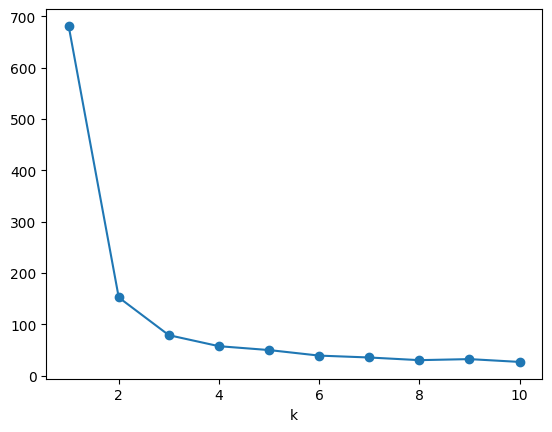

In [4]:
import pandas as pd
import statsmodels.api as sm
from sklearn.cluster import KMeans

# Irisデータセットを読み込む
iris = sm.datasets.get_rdataset('iris', 'datasets').data
my_data = iris.iloc[:, 0:4]

# クラスタ数を1から10の範囲で変えながら，当てはまり度合いを可視化する
k = range(1, 11)
my_df = pd.DataFrame({
    'k': k,
    'inertia': [KMeans(k, n_init="auto").fit(my_data).inertia_ for k in range(1, 11)]})
my_df.plot(x='k', style='o-', legend=False)

このグラフの縦軸はクラスタ内の「異質性」，要するにモデルの当てはまり具合（クラスタ中心からの誤差の総和）を示している．

クラスタ数が多くなると，クラスタ内に「異質」なインスタンスが少なくなるので，異質性が下がる．

異質性の下がり方が鈍るところ（この例ではk=2 または 3）をエルボー点という．

これがクラスタ数の目安となる．

 非階層的クラスタ分析の結果を可視化する．

In [5]:
!pip3 install pca

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.4/190.4 kB 13.6 MB/s eta 0:00:00


[18-05-2026 09:47:51] [pca.pca] [INFO] Column labels are auto-completed.
[18-05-2026 09:47:51] [pca.pca] [INFO] Row labels are auto-completed.
[18-05-2026 09:47:51] [pca.pca] [INFO] PCA reduction performed to capture at least 95.0% explained variance using 4 columns of the input data.
[18-05-2026 09:47:51] [pca.pca] [INFO] Fit using PCA.
[18-05-2026 09:47:51] [pca.pca] [INFO] Compute loadings and PCs.
[18-05-2026 09:47:51] [pca.pca] [INFO] Compute explained variance.
[18-05-2026 09:47:51] [pca.pca] [INFO] The top 2 principal component(s) explains >= 95.00% of the explained variance.
[18-05-2026 09:47:51] [pca.pca] [INFO] The PCA reduction is performed on 4 variables (columns) of the input dataframe.
[18-05-2026 09:47:51] [pca.pca] [INFO] Fit using PCA.
[18-05-2026 09:47:51] [pca.pca] [INFO] Compute loadings and PCs.
[18-05-2026 09:47:51] [pca.pca] [INFO] Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[2]
[18-05-2026 09:47:51] [pca.pca] [INFO] Multiple test

<Axes: xlabel='PC1', ylabel='PC2'>

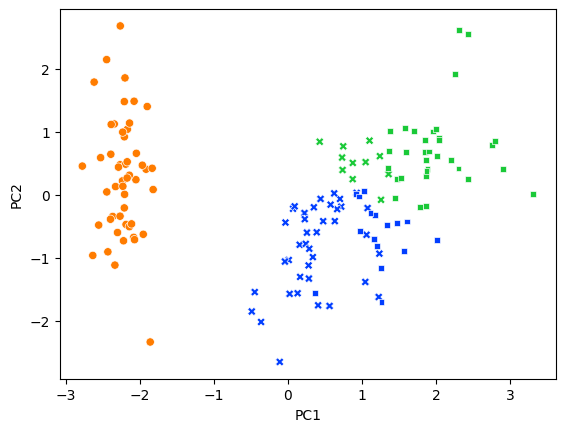

In [6]:
import seaborn as sns
import statsmodels.api as sm
from pca import pca
from scipy.cluster import hierarchy
from scipy.stats import zscore
from sklearn.cluster import KMeans

iris = sm.datasets.get_rdataset('iris', 'datasets').data
my_data = zscore(iris.iloc[:, 0:4])

my_model = pca() # 主成分分析
my_result = my_model.fit_transform(my_data)['PC']
my_result['Species'] = list(iris.Species)

# 非階層的クラスタ分析の場合
my_result['cluster'] = KMeans(n_clusters=3, n_init="auto").fit(my_data).labels_

# 階層的クラスタ分析の場合
#my_result['cluster'] = hierarchy.cut_tree(
#    hierarchy.linkage(my_data, method='complete'), 3)[:,0]

sns.scatterplot(x='PC1', y='PC2', data=my_result, legend=False,
                hue='cluster',   # 色でクラスタを表現する．
                style='Species', # 形で品種を表現する．
                palette='bright')

インスタンスが，色（クラスタ）ごとにまとまって分布していることが分かる．

主成分分析とクラスタ分析の結果が整合している．